# Project Delphi (Merlin)

## 03a - Model Training: Views (XGBoost)

### Overview:

In this notebook, we'll train the first of our two XGBoost models. This first mode will predict total lifetime views trained on the feature-rich dataset we built in the `02_title_embeddings` notebook.

To address the strong right-skew in view counts, we apply a log transformation to the target variable -- stabilizing variance, improving interpretability, and helping the model generalize better. This notebook marks the transition from raw feature engineering to fine-tuned model training, establishing a reusable pipeline that will also be utilized for the subscribers model.

---

### The Plan:
1. **Load** the feature-rich dataset created in `02_title_embeddings`
2. **Define** the features (numberic + embeddings) and target variables
3. **Split** the data into training and test sets
4. **Train** the XGBoost model
5. **Evaluate** the model performance using metrics like MAE, RMSE, and R²
6. **Apply** a log transformation to the `views_lifetime` target to create a `views_lifetime_log` column
7. **Fine-tune** the baseline XGBoost model with `RandomizedSearchCV`
8. **Save** the artifacts for downstream deployment in Merlin:
   - `xgb_views_model.pkl` (trained model)
   - `features_views.json` (feature list and order)
   - `views_model_meta.json` (model metadata (CV RMSE, params, sizes)

---

### Why this Matters
Training these models gives our system predictive power:
- Normalizes the heavy-tailed views counts for more stable learning
- Captures both types of features (numeric + embeddings)
- It lays the foundation for **Merlin's interactive what-if engine**, where creators can test ideas and iterate intelligently

## Load the feature-rich dataset

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Start by importing pandas and then load the dataset
import pandas as pd
data_path = '/content/drive/MyDrive/Colab Notebooks/project_delphi/data/project_delphi_with_embeddings.pkl'
df = pd.read_pickle(data_path)

# Display the first few rows
df.head()

,title,duration_seconds,day_of_week,month,views_lifetime,subs_lifetime,embed_0,embed_1,embed_2,embed_3,...,embed_374,embed_375,embed_376,embed_377,embed_378,embed_379,embed_380,embed_381,embed_382,embed_383
0,Radio Layoffs Hit KNBR (Again) - Damon & Sam B...,5306.0,3,10,10666.0,45.0,-0.032426,0.004222,-0.051053,-0.048461,...,0.032988,-0.036669,-0.082085,0.019063,-0.062317,-0.000892,-0.088869,-0.032865,-0.091954,0.036114
1,Analysis: 49ers Lose To Lions In Disastrous Fa...,5234.0,1,11,5617.0,5.0,-0.046510,0.020991,-0.119065,0.021533,...,0.056652,0.021922,-0.033295,-0.063782,-0.070290,0.008837,0.021913,0.035472,0.017452,0.007911
2,"49ers Insider Matt Maiocco Talks Trades, QB Co...",4611.0,1,9,5246.0,13.0,-0.092190,-0.081139,-0.097148,0.006893,...,0.021139,0.039691,-0.008243,0.007969,-0.036037,0.009903,-0.057307,0.029755,-0.006915,0.087668
3,"49ers Analysis: Campbell Is A LOSER, Purdy TER...",5875.0,4,11,4995.0,9.0,-0.069882,-0.004827,-0.073440,-0.000911,...,0.084864,0.018908,-0.079154,-0.021822,-0.078934,0.033437,0.010721,-0.007301,0.048347,0.006759
4,49ers Analysis: Embarrassing Late-Game Loss vs...,7007.0,0,11,4814.0,37.0,-0.056615,0.003609,-0.061708,0.000720,...,0.116987,-0.016363,-0.048928,-0.050522,-0.121011,0.020156,-0.032676,0.002244,-0.048972,0.029054


In [ ]:
# Quickly confirm the shape
df.shape

(298, 390)

## Define the features and target variable

For this first model, we'll use the numeric features (less `title`) and the embeddings to predict `views_lifetime`.

In [ ]:
# Define the target and the features -- the numeric inputs and the embedding
# First, set y -- the target as views_lifetime
target = 'views_lifetime'

# Important note: Need to drop the target -- views_lifetime, plus subs_lifetime and also
# title, which provides no predictive power, hence why we embedded it!

X = df.drop(columns=['views_lifetime', 'subs_lifetime', 'title'])
print(X.shape)

# And now set y
y = df[target]
print(y.shape)

(298, 387)
(298,)


## Split the data into training and test sets

Given the limited size of the dataset, we've forget creating a separate validation set. Instead, we'll do an 80/20 split for training and validation and then run 5-fold cross validation on the training set to get a more reliable estimate.

In [ ]:
# Import train_test_split and cross_val_score from sklearn
from sklearn.model_selection import train_test_split, cross_val_score

# Split the training and test sets 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Check the shapes of the training and tests sets
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(238, 387)
(60, 387)
(238,)
(60,)


## Run cross-validation and train the XGBoost model

Now, to run cross-validation. We'll intialize the XGBoost regressor with balanced, general-purpose hyperparameters -- enough depth to capture non-liner patterns, but conservative enough to try not to overfit on the small dataset.

In [ ]:
# Start by importing XGBoost
import xgboost as xgb
import numpy as np

# Initialize the model
# Note:
# n_estimators: The number of boosting rounds, or trees
# A low learning rate: This safer, lower learning rate limits how much each tree contributes
# max_dpeth: Controls model complexity; So, deeper trees, more likely to overfit
# subsample: The fraction of training rows used per tree -- like "row dropout"
# colsample_bytree: The fraction of features samples per tree -- like "feature dropout"
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

# Run 5-fold cross-validation on the training set
# Each fold trains on 80% of the data and validates on 20%, rotating 5 times
# Note: sckit-learn stores loss metrics as negative (since it always maximzies scores);
# So, we multiple by -1 to turn RMSE back into a positive, human-readable value
cv_scores = cross_val_score(
    model, X_train, y_train,
    cv=5, scoring="neg_root_mean_squared_error"
)

# Display the results
# Note: Make sure that RMSE is positive for readibility
print("Cross-val RMSE:", -cv_scores)
print("Mean CV RMSE:", np.mean(-cv_scores))

Cross-val RMSE: [1050.17826553 1327.67739921 1581.85122041  956.79477209  926.30718503]
Mean CV RMSE: 1168.561768454159


That baseline RMSE -- just over 1.1K views -- is quite large in the context of out dataset. Let's take a closer at the data to see how to proceed.

In [ ]:
# Check the summary stats
df.views_lifetime.describe()

,views_lifetime
count,298.000000
mean,1795.338926
std,1019.305333
min,311.000000
25%,1149.250000
50%,1601.000000
75%,2155.250000
max,10666.000000


## Plot first, model second

Before applying any transformations, let's visualize the `views_lifetime` to confirm the right skew we expect.

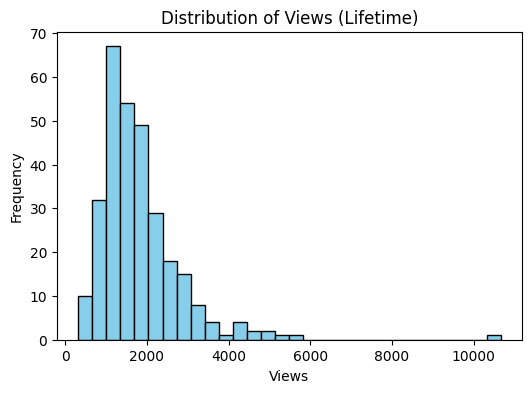

In [ ]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Plot the distribution of "views_lifetime"
plt.figure(figsize=(6,4))
plt.hist(df['views_lifetime'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Views (Lifetime)")
plt.xlabel("Views")
plt.ylabel("Frequency")

# Display the plot
plt.show()

This is *exactly* what we were expecting to see: a cluster of videos around 2K views with a long tail of outliers past 10K. That shape is what led to our inflated RMSE.

## Apply a log transformation to stabilize the target

Since the distribution of `views_lifetime` is heavily right-skewed, we'll apply a **log transformation** to make it a more normal-like distribution and reduce the influence of outliers.

**Intuition:** Log transformation compresses large values and expands small ones -- turning multiplicative relationships (“10× more views”) into additive ones (“+1 unit in log-space”). This stabilizes variance and helps the model learn smoother, more interpretable patterns.


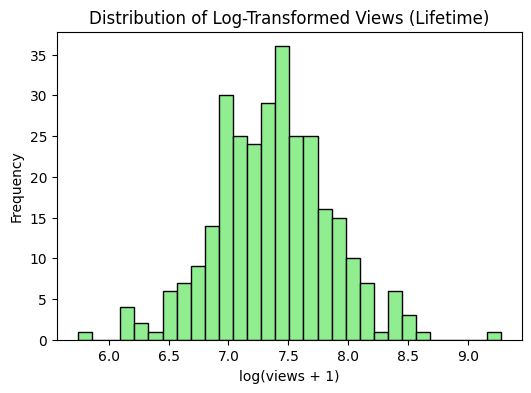

In [ ]:
# First, create a log-transformed version of the target
df['views_lifetime_log'] = np.log1p(df['views_lifetime'])

# Now, quickly visualize the new distribution
plt.figure(figsize=(6,4))
plt.hist(df['views_lifetime_log'], bins=30, color='lightgreen', edgecolor='black')
plt.title("Distribution of Log-Transformed Views (Lifetime)")
plt.xlabel("log(views + 1)")
plt.ylabel("Frequency")
plt.show()

That's the exact data distribution we were looking for. Now, we'll train on the log-scaled target (`views_lifetime_log`) instead of the raw values.

In [ ]:
# Redefine our target variable
y = df['views_lifetime_log']

# Drop the unused target columns
X = df.drop(columns=['views_lifetime', 'views_lifetime_log', 'subs_lifetime', 'title'])

# Check the shapes of the updated X and y
print(X.shape)
print(y.shape)

(298, 387)
(298,)


We’ll **save the DataFrame with the new log-transformed column** so we can reload it quickly without rerunning earlier steps.

In [ ]:
# Firs define save path -- same place as all the other datasets for this project
save_path = '/content/drive/MyDrive/Colab Notebooks/project_delphi/data/project_delphi_with_log.pkl'

# Save the updated DataFrame
df.to_pickle(save_path)
print(f"✅ Updated dataset saved to: {save_path}")


✅ Updated dataset saved to: /content/drive/MyDrive/Colab Notebooks/project_delphi/data/project_delphi_with_log.pkl


Now, we're ready to split, train and cross-validate just as we did before.

In [ ]:
# Split the training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Check the shapes
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(238, 387)
(60, 387)
(238,)
(60,)


Next, we'll train and cross-validate using the block from above as our template.

In [ ]:
# Initialize the model
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

# Run 5-fold cross-validation (still using RMSE as the metric)
cv_scores = cross_val_score(
    model, X_train, y_train,
    cv=5, scoring="neg_root_mean_squared_error"
)

# Display results
print("Cross-val RMSE (log-space):", -cv_scores)
print("Mean CV RMSE (log-space):", np.mean(-cv_scores))

Cross-val RMSE (log-space): [0.47396922 0.32909869 0.55214641 0.44664086 0.47619688]
Mean CV RMSE (log-space): 0.4556104135828235


**Baseline takeaway**: Our baseline XGBoost model achieved a mean cross-validated RMSE of **~0.46 in log-space**, a dramatic improvement from the 1,100+ RMSE seen on raw view counts.

The variation across folds (0.33-0.55) shows how performance can fluctuate with such a compact dataset -- reinforcing why cross-validation is so useful for stability checks. Up next, we'll fine-tune the model's hyperparameters with `RandomizedSearchCV` to see if we can tighten this spread and futher reduce overall error.

## Fine-tune the baseline XGBoost model with `RandomizedSearchCV`

The goal is to find the best combination of hyperparameters that minimizes RMSE in log space. We'll do this by using `RandomizedSearchCV` over a defined parameter space. This helps balance model complexity and generalization. especially on small datasets.

In [ ]:
# Start with the imports
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint, uniform, loguniform

In [ ]:
# Define the base XGBoost model
base = xgb.XGBRegressor(
    random_state=42,
    tree_method="hist",
    objective="reg:squarederror"
)

# Define the hyperparameter search space
# Note: The ranges are kept moderate because we only have about 300 samples; Need to avoid overfitting
param_dist = {
    "n_estimators": randint(200, 1200),
    "learning_rate": loguniform(1e-3, 2e-1),
    "max_depth": randint(3, 10),
    "min_child_weight": randint(1, 10), # Acts as a guardrail against overfitting; Prevents splits on small, noisy groups
    "subsample": uniform(0.5, 0.5),         # 0.5 to 1.0
    "colsample_bytree": uniform(0.5, 0.5),  # 0.5 to 1.0
    "gamma": uniform(0.0, 2.0),
    "reg_alpha": loguniform(1e-6, 1e-1), # L1 regularization term: Pushes weights toward zero
    "reg_lambda": loguniform(1e-2, 10.0), # L2 regularization term: Penalizes weights to reduce variance
}

# Set up RandomizedSearchCV
# Note: RandomizedSearchCV tries a random parameter combination (here, 40 samples from the grid)
# and uses 5-fold CV to evaluate each one; This is much faster than GridSearchCV
search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_dist,
    n_iter=40,                       # Number of iterations to try
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1, # Parallelize across CPU cores
    verbose=1,
    random_state=42,
    refit=True # Refit the best model at the end
)

# Run the search
search.fit(X_train, y_train)

# Display the best CV RMSE and best set of parameters
print("Best CV RMSE (log-space):", -search.best_score_)
print("Best params:", search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV RMSE (log-space): 0.44090446993332033
Best params: {'colsample_bytree': np.float64(0.9018360384495572), 'gamma': np.float64(0.3731401177720717), 'learning_rate': np.float64(0.1131892099052994), 'max_depth': 5, 'min_child_weight': 7, 'n_estimators': 547, 'reg_alpha': np.float64(6.046293018986847e-05), 'reg_lambda': np.float64(5.2539426107000855), 'subsample': np.float64(0.6360661246923176)}


The RandomizedSearchCV was a clear success, improving our baseline Mean CV RMSE from 0.4556 down to 0.4409.

The search landed on a cautious and robust set of parameters. For example, it chose a max_depth=5, proving that shallow, simple trees are the best way to prevent overfitting on our small, high-dimensional dataset.

Now that we have our final, optimized model (`search.best_estimator_`), it's time to evaluate how our model generalizes to unseen data.

## Evaluate the model on the test set

In [ ]:
# Evaluate best model on the test set (still in log-space)
best_model = search.best_estimator_
y_pred_log = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_log)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_log)
r2  = r2_score(y_test, y_pred_log)
print(f"Test RMSE (log-space): {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")

# Optional: back-transform for intuition (approximate median absolute error in views)
y_pred_views = np.expm1(y_pred_log)
y_true_views = np.expm1(y_test)
print("Back-transformed median |y_true - y_pred|:", np.median(np.abs(y_true_views - y_pred_views)).round(1))

Test RMSE (log-space): 0.392 | MAE: 0.305 | R²: 0.169
Back-transformed median |y_true - y_pred|: 377.3


**Takeaway**: The fine-tuning was a success. Our optimized model performed exceptionally well on the unseen test set, achieving a final Test RMSE (log-space) of 0.392. This confirms our model is robust and can generalize to new data, not just memorize the training set.

But the most important metric is the *so what* for the host. By back-trasnforming our error, we got a median absolute error of 377.3.

**This is a key business result: for a typical video, our model can predict its total views with an average error of only 377 views**. This is a strong result given the small dataset and natural variability in YouTube performance, proving the model is more than accurate enough to help the host iterate and A/B test new titles.

## Save the artifacts for Deployment in Merlin

In [ ]:
import joblib
import xgboost as xgb
from pathlib import Path

# 1. Path to where you ALREADY saved the model (No re-training needed!)
# Based on your notebook, this is exactly where it lives:
model_path = Path("/content/drive/MyDrive/Colab Notebooks/project_delphi/models/xgb_views_model.pkl")

print(f"Attempting to load: {model_path}")

# 2. Load the 'frozen' model from the disk
# This typically takes < 1 second
try:
    loaded_model = joblib.load(model_path)
    print("✅ Model loaded successfully from disk.")
except FileNotFoundError:
    print("❌ ERROR: Could not find the .pkl file. Did you verify Google Drive is mounted?")
    print(f"Looking at: {model_path}")
    # Stop if not found
    raise

# 3. Extract the XGBoost 'Booster' (the core math part)
# This handles whether you saved the Search object or the Model object
if hasattr(loaded_model, "best_estimator_"):
    # It was a RandomizedSearchCV object
    booster = loaded_model.best_estimator_.get_booster()
else:
    # It was a direct XGBRegressor
    booster = loaded_model.get_booster()

# 4. Save as UBJSON (The "Universal" format that fixes the Mac bug)
save_path = model_path.parent / "xgb_views_booster.ubjson"
booster.save_model(save_path)

print("------------------------------------------------")
print(f"✅ SUCCESS! The safe file is ready.")
print(f"👉 Go to your Google Drive folder: {model_path.parent}")
print("👉 Download: xgb_views_booster.ubjson")
print("------------------------------------------------")

Attempting to load: /content/drive/MyDrive/Colab Notebooks/project_delphi/models/xgb_views_model.pkl
✅ Model loaded successfully from disk.
------------------------------------------------
✅ SUCCESS! The safe file is ready.
👉 Go to your Google Drive folder: /content/drive/MyDrive/Colab Notebooks/project_delphi/models
👉 Download: xgb_views_booster.ubjson
------------------------------------------------


/tmp/ipython-input-2878971085.py:33: UserWarning: [04:33:21] WARNING: /workspace/src/c_api/c_api.cc:1575: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  booster.save_model(save_path)


In [ ]:
# Save the trained XGBoost views model and feature schema
import joblib, json
from pathlib import Path

# Define model directory (same path style as 03b)
MODELS = Path("/content/drive/MyDrive/Colab Notebooks/project_delphi/models")
MODELS.mkdir(parents=True, exist_ok=True)

# Save the tuned views model
joblib.dump(best_model, MODELS / "xgb_views_model.pkl")
views_booster = best_model.get_booster()
views_booster.save_model(MODELS / "xgb_views_booster.json")
print("✅ Saved: xgb_views_booster.json")

# Save the feature order (column names + order) as JSON
feature_cols = list(X_train.columns)
with open(MODELS / "features_views.json", "w") as f:
    json.dump({"feature_cols": feature_cols}, f)
print("✅ Saved: features_views.json")

# Quick print statement as a check
print("All artifacts saved successfully in:", MODELS)

✅ Saved: xgb_views_booster.json
✅ Saved: features_views.json
All artifacts saved successfully in: /content/drive/MyDrive/Colab Notebooks/project_delphi/models


In [ ]:
import json
import numpy as np
import pandas as pd
import xgboost as xgb
from sentence_transformers import SentenceTransformer
from pathlib import Path

MODELS = Path("/content/drive/MyDrive/Colab Notebooks/project_delphi/models")

# Load booster + schema
booster_views = xgb.Booster()
booster_views.load_model(MODELS / "xgb_views_booster.json")

with open(MODELS / "features_views.json") as f:
    views_schema = json.load(f)["feature_cols"]

# SAME test input as local
title = "49ers lose to the Rams"
duration_min = 30
day_name = "Monday"
month_name = "January"

day_options = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
month_options = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

day_idx = day_options.index(day_name)
month_idx = month_options.index(month_name)

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
title_vec = embedder.encode([title])[0]

feat = {
    "duration_seconds": duration_min * 60.0,
    "day_of_week": day_idx,
    "month": month_idx,
}
for i in range(len(title_vec)):
    feat[f"embed_{i}"] = float(title_vec[i])

df_input = pd.DataFrame([feat])
X_views = df_input.reindex(columns=views_schema, fill_value=0.0)

y_views_log = booster_views.predict(xgb.DMatrix(X_views))[0]
y_views = int(max(0, round(np.expm1(y_views_log))))

print("COLAB booster log:", y_views_log)
print("COLAB booster views:", y_views)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

COLAB booster log: 7.5133767
COLAB booster views: 1831


In [ ]:
# Recreate smoke test for debugging
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
import json

# Load the same embedder used in notebook 02
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# LOAD YOUR FEATURE SCHEMA (same path as 03 in Colab)
with open("/content/drive/MyDrive/Colab Notebooks/project_delphi/models/features_views.json") as f:
    views_schema = json.load(f)["feature_cols"]

# Test input (same used locally)
title = "49ers lose to the Rams"
duration_min = 30
day_name = "Monday"
month_name = "January"

day_options = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
month_options = ["January","February","March","April","May","June","July","August","September","October","November","December"]

day_idx = day_options.index(day_name)
month_idx = month_options.index(month_name)

# Encode
title_vec = embedder.encode([title], normalize_embeddings=True)[0]

# Build feature dict
feat = {
    "duration_seconds": duration_min * 60.0,
    "day_of_week": day_idx,
    "month": month_idx,
}
for i in range(len(title_vec)):
    feat[f"embed_{i}"] = float(title_vec[i])

df_input = pd.DataFrame([feat])
X_views = df_input.reindex(columns=views_schema, fill_value=0.0)

# ---- PRINT FOR COMPARISON ----
print("COLAB title_vec[:8]:", title_vec[:8])
print("COLAB X_views first 5:", X_views.iloc[0, :5].to_dict())

COLAB title_vec[:8]: [-0.03436629  0.03224089 -0.02245461  0.00935729 -0.03418518  0.04915732
  0.03053389  0.0170774 ]
COLAB X_views first 5: {'duration_seconds': 1800.0, 'day_of_week': 0.0, 'month': 0.0, 'embed_0': -0.034366291016340256, 'embed_1': 0.03224089369177818}


In [1]:
# NOTE: This cell is commented because this copy of the model is deprecated
# Save UBJSON because this format is much safer for moving between Colab (Linux) and Mac
# booster = best_model.get_booster()
# booster.save_model(MODELS / "xgb_views_booster.ubjson")

# print("✅ SAVED SAFE MODEL: xgb_views_booster.ubjson")
# print("👉 Download this specific file and put it in your local 'models' folder.")